In [1]:
!pip install -q transformers accelerate pillow

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# --- PROMPT ---
prompt_text = """
You are an AI system specialized in understanding Vietnamese receipt images.

The input is a photo of a RECEIPT written in Vietnamese.

Your task is to extract the following information EXACTLY as it appears on the receipt:

- "SELLER": Tên cửa hàng / đơn vị bán hàng.
- "ADDRESS": Địa chỉ của cửa hàng.
- "TIMESTAMP": Ngày và giờ giao dịch (nếu chỉ có ngày thì trả về ngày).
- "TOTAL_COST": Tổng số tiền phải thanh toán (chỉ giá trị tổng, không bao gồm các dòng khác).

IMPORTANT RULES:
- The receipt language is Vietnamese.
- DO NOT translate the content.
- DO NOT infer or guess missing information.
- ONLY extract text that clearly appears on the receipt image.
- If a field is not found, return null.
- Keep numbers, symbols, and formatting as close to the original text as possible.

OUTPUT FORMAT:
- Return STRICTLY a valid JSON object.
- DO NOT include explanations, comments, or extra text.
- DO NOT wrap the JSON in markdown.

Example output:
{
  "SELLER": "CỬA HÀNG TIỆN LỢI ABC",
  "ADDRESS": "123 Nguyễn Trãi, Quận 1, TP.HCM",
  "TIMESTAMP": "12/03/2024 18:45",
  "TOTAL_COST": "235.000"
}
"""

In [4]:
import os
import re
import random
import json
import pandas as pd
from PIL import Image
from collections import Counter

import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

In [5]:
MODEL_NAME = "Qwen/Qwen2.5-VL-7B-Instruct"

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model-00005-of-00005.safetensors:   0%|          | 0.00/1.09G [00:00<?, ?B/s]

model-00002-of-00005.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear(in_features=1280, out_features=3840, bias=True)
            (proj): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
            (act_fn): SiLUAc

In [6]:
def qwen_infer(image, prompt):
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt}
        ]
    }]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        ids = model.generate(
            **inputs,
            max_new_tokens=300,
            do_sample=False
        )

    return processor.batch_decode(ids, skip_special_tokens=True)[0]

In [7]:
IMAGE_FOLDER = "/content/drive/MyDrive/CS406/Project/Dataset/train_images"
TSV_FOLDER   = "/content/drive/MyDrive/CS406/Project/Dataset/processed_tsv"

N_SAMPLES = 1
TARGET_LABELS = ["SELLER", "ADDRESS", "TIMESTAMP", "TOTAL_COST"]

In [22]:
def normalize(t):
    return re.sub(r"\s+", " ", t.lower()).strip() if isinstance(t, str) else ""

def load_tsv(tsv_path):
    df = pd.read_csv(tsv_path, sep=",", header=None)

    if df.shape[1] != 11:
        raise ValueError(f"{tsv_path}: expected 11 cols, got {df.shape[1]}")

    df.columns = [
        "id","x1","y1","x2","y2",
        "x3","y3","x4","y4","text","label"
    ]

    return [
        (normalize(str(r.text)), r.label)
        for _, r in df.iterrows()
        if isinstance(r.text, str) and r.text.strip()
    ]

def parse_output(text):
    results = []
    try:
        m = re.search(r"\{.*\}", text, re.DOTALL)
        if m:
            data = json.loads(m.group(0))
            for k, v in data.items():
                if k in TARGET_LABELS and v:
                    results.append((normalize(str(v)), k))
    except:
        pass
    return results

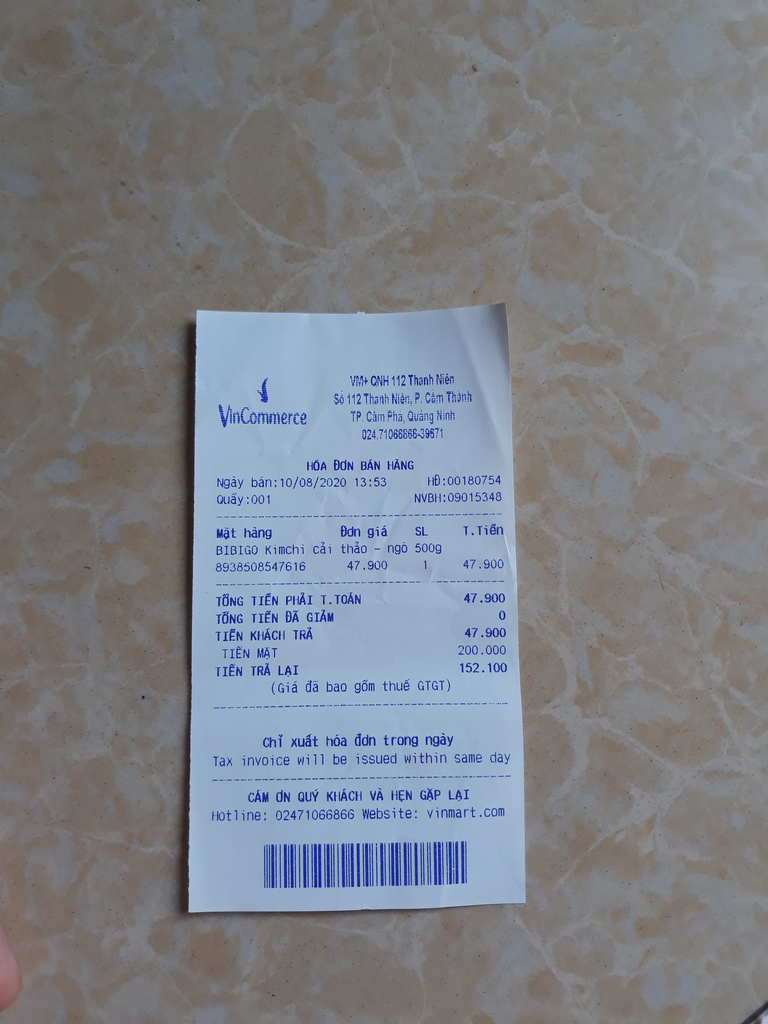

Image selected: mcocr_public_145014fhbos.jpg
📦 PARSED JSON:
system
You are a helpful assistant.
user

You are an AI system specialized in understanding Vietnamese receipt images.

The input is a photo of a RECEIPT written in Vietnamese.

Your task is to extract the following information EXACTLY as it appears on the receipt:

- "SELLER": Tên cửa hàng / đơn vị bán hàng.
- "ADDRESS": Địa chỉ của cửa hàng.
- "TIMESTAMP": Ngày và giờ giao dịch (nếu chỉ có ngày thì trả về ngày).
- "TOTAL_COST": Tổng số tiền phải thanh toán (chỉ giá trị tổng, không bao gồm các dòng khác).

IMPORTANT RULES:
- The receipt language is Vietnamese.
- DO NOT translate the content.
- DO NOT infer or guess missing information.
- ONLY extract text that clearly appears on the receipt image.
- If a field is not found, return null.
- Keep numbers, symbols, and formatting as close to the original text as possible.

OUTPUT FORMAT:
- Return STRICTLY a valid JSON object.
- DO NOT include explanations, comments, or extra text

In [23]:
import os
import random
from PIL import Image

# chọn ngẫu nhiên 1 ảnh
fname = random.choice(
    [f for f in os.listdir(IMAGE_FOLDER) if f.endswith(".jpg")]
)

img_path = os.path.join(IMAGE_FOLDER, fname)

image = Image.open(img_path).convert("RGB")
display(image)

print(f"Image selected: {fname}")
print("=" * 60)

# load ảnh
image = Image.open(img_path).convert("RGB")

# infer
pred_text = qwen_infer(image, prompt_text)

print("📦 PARSED JSON:")
print(pred_text)